# C4 — Main S1/S2/S3 Scenarios Report

Laporan *read-only* untuk tiga skenario utama: S1 metadata-only, S2 image-only ResNet-50, dan S3 intermediate multimodal fusion. ROC-AUC dan Average Precision merupakan metric prediktif utama; metric threshold 0.5 serta calibration merupakan analisis sekunder/diagnostik.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve, roc_curve

def find_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'run_experiment.py').is_file():
            return candidate
    raise FileNotFoundError('Project root tidak ditemukan')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.reporting.canonical import (
    fold_metric_frame, load_canonical_context, load_oof_predictions, metric_table
)

context = load_canonical_context(PROJECT_ROOT)
model_lock = json.loads((context.protocol_dir / 'model_lock.json').read_text(encoding='utf-8'))
pd.DataFrame([{
    'protocol_version': '1.0.0',
    'status': context.protocol['status'],
    'protocol_hash': context.protocol_hash,
    'selected_backbone': model_lock['selected_backbone'],
    'selected_pretraining': model_lock['selected_pretraining'],
    'images': len(context.folds),
    'patients': context.folds['patient_id'].nunique(),
}])

,protocol_version,status,protocol_hash,selected_backbone,selected_pretraining,images,patients
0,1.0.0,FROZEN,d42337690181f1054297f514934ad0c98bb718223bc06d...,resnet50,imagenet,86524,28008


## Audit artifact dan primary predictive metrics

Notebook memerlukan `main/_SUCCESS` dan meregenerasi seluruh metric dari prediction CSV. Setiap model harus memiliki tepat satu OOF prediction untuk seluruh citra pada `folds.csv`.

In [2]:
stage_dir = context.protocol_dir / 'main'
files = {
    'S1 — Metadata': 'S1-canonical_mlp-not_applicable-D-oof.csv',
    'S2 — Image': 'S2-resnet50-imagenet-D-oof.csv',
    'S3 — Multimodal': 'S3-resnet50-imagenet-D-oof.csv',
}
models = {
    name: load_oof_predictions(
        context, stage_dir / filename, expected_stage_directory='main'
    )
    for name, filename in files.items()
}
reference = next(iter(models.values()))[['image_index', 'patient_id', 'fold', 'true_label']]
for name, frame in models.items():
    pd.testing.assert_frame_equal(
        reference.reset_index(drop=True),
        frame[['image_index', 'patient_id', 'fold', 'true_label']].reset_index(drop=True),
        check_dtype=False,
        obj=f'paired OOF alignment: {name}',
    )
summary = metric_table(models)
display(summary.style.format({
    column: '{:.4f}' for column in summary.columns if column not in {'n_images', 'n_patients'}
}))
print('Audit PASS: 15/15 canonical fold artifacts, paired OOF coverage valid.')

,roc_auc_pooled,roc_auc_mean,roc_auc_sd,ap_pooled,ap_mean,ap_sd,brier_score,accuracy_0.5,sensitivity_0.5,specificity_0.5,f1_0.5,n_images,n_patients
model,,,,,,,,,,,,,
S1 — Metadata,0.6214,0.6227,0.0040,0.5192,0.5220,0.0051,0.2409,0.5812,0.6308,0.5459,0.5564,86524,28008
S2 — Image,0.7524,0.7535,0.0022,0.6729,0.6742,0.0031,0.2002,0.7045,0.6264,0.7602,0.6383,86524,28008
S3 — Multimodal,0.7534,0.7541,0.0032,0.6717,0.6733,0.0048,0.2004,0.7041,0.6356,0.7529,0.6414,86524,28008


Audit PASS: 15/15 canonical fold artifacts, paired OOF coverage valid.


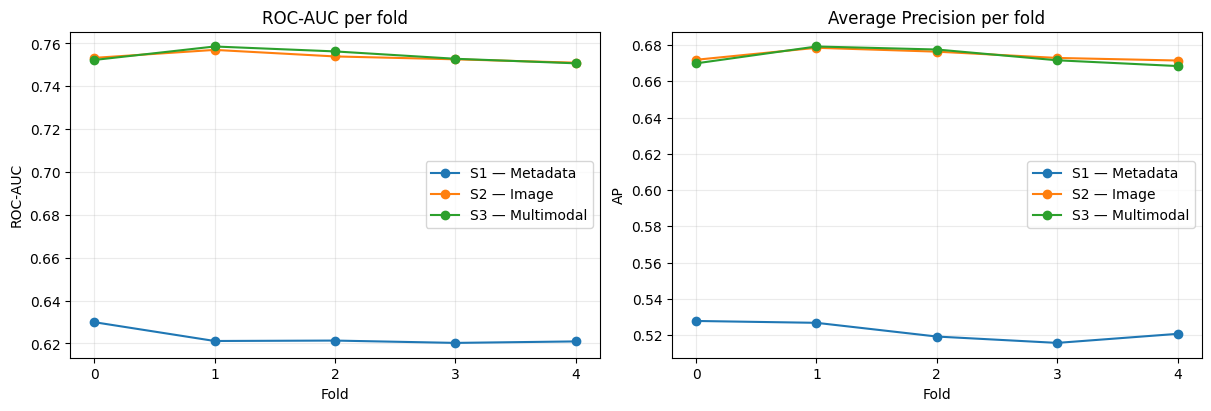

In [3]:
folds = fold_metric_frame(models)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, group in folds.groupby('model', sort=False):
    axes[0].plot(group['fold'], group['roc_auc'], marker='o', label=name)
    axes[1].plot(group['fold'], group['average_precision'], marker='o', label=name)
axes[0].set(title='ROC-AUC per fold', xlabel='Fold', ylabel='ROC-AUC', xticks=range(5))
axes[1].set(title='Average Precision per fold', xlabel='Fold', ylabel='AP', xticks=range(5))
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

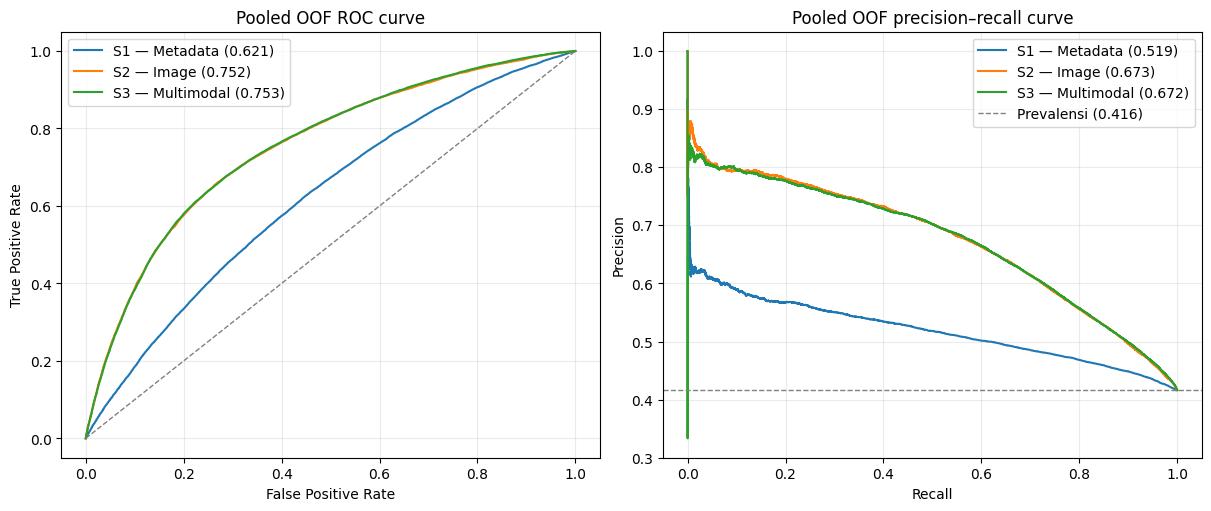

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
prevalence = reference['true_label'].mean()
for name, frame in models.items():
    fpr, tpr, _ = roc_curve(frame['true_label'], frame['probability'])
    precision, recall, _ = precision_recall_curve(frame['true_label'], frame['probability'])
    axes[0].plot(fpr, tpr, label=f"{name} ({summary.loc[name, 'roc_auc_pooled']:.3f})")
    axes[1].plot(recall, precision, label=f"{name} ({summary.loc[name, 'ap_pooled']:.3f})")
axes[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
axes[1].axhline(prevalence, linestyle='--', color='grey', linewidth=1, label=f'Prevalensi ({prevalence:.3f})')
axes[0].set(title='Pooled OOF ROC curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].set(title='Pooled OOF precision–recall curve', xlabel='Recall', ylabel='Precision')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

## Secondary threshold-dependent metrics

Confusion matrix berikut menggunakan threshold 0.5 yang telah ditetapkan. Angka ini tidak digunakan sebagai pengganti ROC-AUC/AP.

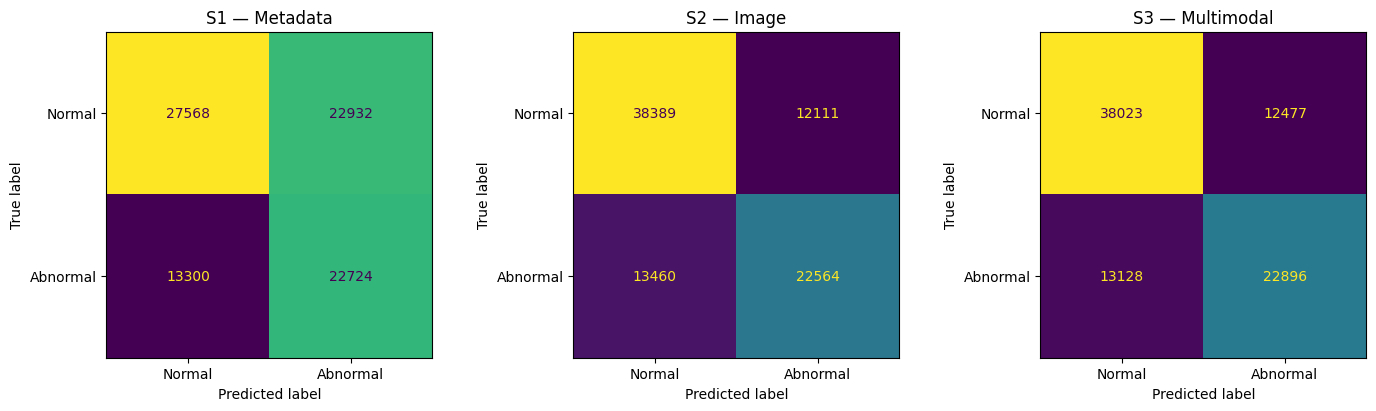

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, (name, frame) in zip(axes, models.items()):
    matrix = confusion_matrix(frame['true_label'], frame['probability'] >= 0.5, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=['Normal', 'Abnormal']).plot(
        ax=axis, colorbar=False, values_format='d'
    )
    axis.set_title(name)
plt.show()

## Diagnostic calibration assessment

Reliability diagram memakai 10 uniform bins pada [0,1]. Empty bins disimpan sebagai NaN. Karena weighted BCE digunakan, sigmoid output disebut skor model dan tidak diklaim sebagai calibrated probability.

,model,bin,lower,upper,count,mean_score,observed_fraction
0,S1 — Metadata,1,0.0,0.1,0,NaN,NaN
1,S1 — Metadata,2,0.1,0.2,0,NaN,NaN
2,S1 — Metadata,3,0.2,0.3,0,NaN,NaN
3,S1 — Metadata,4,0.3,0.4,11648,0.371292,0.243733
4,S1 — Metadata,5,0.4,0.5,29220,0.456781,0.358008
5,S1 — Metadata,6,0.5,0.6,34762,0.548545,0.475117
6,S1 — Metadata,7,0.6,0.7,9632,0.629655,0.563331
7,S1 — Metadata,8,0.7,0.8,1083,0.737560,0.606648
8,S1 — Metadata,9,0.8,0.9,167,0.836681,0.682635
9,S1 — Metadata,10,0.9,1.0,12,0.907541,0.916667


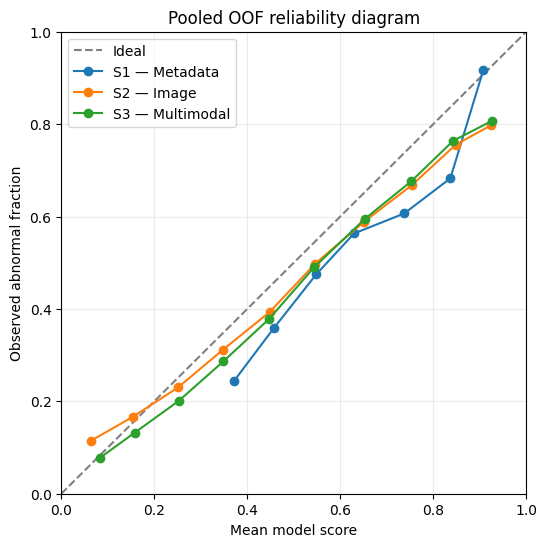

In [6]:
def uniform_calibration(frame, bins=10):
    edges = np.linspace(0.0, 1.0, bins + 1)
    probabilities = frame['probability'].to_numpy(float)
    labels = frame['true_label'].to_numpy(int)
    assignments = np.digitize(probabilities, edges[1:-1], right=False)
    rows = []
    for index in range(bins):
        selected = assignments == index
        rows.append({
            'bin': index + 1,
            'lower': edges[index],
            'upper': edges[index + 1],
            'count': int(selected.sum()),
            'mean_score': float(probabilities[selected].mean()) if selected.any() else np.nan,
            'observed_fraction': float(labels[selected].mean()) if selected.any() else np.nan,
        })
    return pd.DataFrame(rows)

calibration = pd.concat(
    [uniform_calibration(frame).assign(model=name) for name, frame in models.items()],
    ignore_index=True,
)
display(calibration[['model', 'bin', 'lower', 'upper', 'count', 'mean_score', 'observed_fraction']])

fig, axis = plt.subplots(figsize=(6, 6))
axis.plot([0, 1], [0, 1], '--', color='grey', label='Ideal')
for name, group in calibration.groupby('model', sort=False):
    valid = group['count'] > 0
    axis.plot(group.loc[valid, 'mean_score'], group.loc[valid, 'observed_fraction'], marker='o', label=name)
axis.set(title='Pooled OOF reliability diagram', xlabel='Mean model score', ylabel='Observed abnormal fraction', xlim=(0, 1), ylim=(0, 1))
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## Descriptive main effect

Selisih S3−S2 di bawah hanya point estimate deskriptif. Patient-cluster bootstrap 95% CI dan inferensi utama ditempatkan pada C6 agar tidak terjadi duplikasi atau klaim prematur.

In [7]:
s2 = 'S2 — Image'
s3 = 'S3 — Multimodal'
effects = pd.DataFrame([{
    'estimand': 'S3-D minus S2',
    'delta_roc_auc': summary.loc[s3, 'roc_auc_pooled'] - summary.loc[s2, 'roc_auc_pooled'],
    'delta_average_precision': summary.loc[s3, 'ap_pooled'] - summary.loc[s2, 'ap_pooled'],
    'delta_brier_score': summary.loc[s3, 'brier_score'] - summary.loc[s2, 'brier_score'],
}])
display(effects.style.format({column: '{:+.4f}' for column in effects.columns if column != 'estimand'}))
print('Interpretasi inferensial ditunda sampai paired patient-cluster bootstrap C6 selesai.')

,estimand,delta_roc_auc,delta_average_precision,delta_brier_score
0,S3-D minus S2,+0.0010,-0.0012,+0.0002


Interpretasi inferensial ditunda sampai paired patient-cluster bootstrap C6 selesai.
